# Kaggriculture Tutorial

Farm your way to market dominance! Players harvest produce and animal products to sell in a dynamic market.

## Game Mechanics 
 
- **Farmer**: takes one action per turn over a season with 30 days and 24 turns per day (720 total).
- **Crops and animals**: each have their own seed cost, time to first yield, and total payout. 
- **Daily care**: 
    - plants need watering every day or they turn to weeds
    - animals need feeding or they escape.
- **Market prices**: move with supply, selling a product pushes its price down, and crops vary in how hard they crash from a glut.
- **Town shops** unlock over the season and steadily buy products, lifting prices over time.
- **Farm hands** can be hired for the day, with increasing costs for each hire per day. 
- **Farm expansion**: start with one quadrant of land and can buy the other three for an escalating fee.
- **Shed**: holds harvested goods but caps at 100 items, anything past that is discarded at end of day.
 - **Win condition**: whoever has the most money in the bank at the end of the season wins.

## Game Design

> **1. Calculate the expected cash return, land return, time return, action cost, feed cost, and market-price sensitivity for every crop/animal, then determine what the agent should plant under different days, cash levels, land availability, and market prices.**
> 
> **2. Determine what the agent should plant under different days, cash levels, land availability, and market prices**

**Farm Production Model**

```text
                    ┌── LAND
                    │
                    ├── CAPITAL (INVENTORY STASH)
                    │
                    ├── LABOR (HIRED HANDS)
                    │
                    ├── SEEDS / ANIMALS
                    │
                    └── FERTILIZER
                         │
                         ▼
                    PRODUCTION
                         │
                         ▼
                      HARVEST
                         │
                         ▼
                  ┌──── MARKET ────┐
                  │                │
             Sell now          Hold inventory
                  │                │
                  ▼                ▼
                CASH          Future sale
```
**Variables**

- COSTS
    - FIXED
        - land
        - coop
        - pasture
    - VARIABLE
        - seed
        - fertilizer
        - animal feed
        - farmer actions + farm-hand hiring

**Key Signals**

- `Max Yield Per Tile`: Units produced/tile/day measures Land efficiency i.e. how efficiently am I using scarce farm space or my current given resources.
- `Profit per dollar invested`: Capital efficiency i.e how efficiently am I converting my starting money into more money.
- `Profit/day`: Time efficiency i.e. how quickly this investment return capital
-  Market impact from produce i.e. how my production or opponents behavior could effect the selling price


## Examples

> **Example 1.1:** 
> 
> Melon's first yield day is 10 and max yield day is 12, suggests it starts returning $ on 10th day and is maxed out on the 12th.

```text
Yield
  6 |                         ████
    |                     ████████
    |                 ████████████
    |             ████████████████
    |         ████████████████████
    |     ████████████████████████
    +--------------------------------
        Day 0    8    10    12
                       ↑     ↑
                   harvest  max
                   begins   yield
```

> **Example 1.2:** 
> 
> Continuous Crops like tomato and strawberry follows the following pattern

```text
Day 0                 Day 8       Day 9       Day 10       Day 11
 │                     │           │           │            │
Plant ────────────────►Harvest ───►Harvest ───►Harvest ────►Harvest
                           ↑           ↑           ↑
                         +4?         +4?         +4?
```


> **Example 1.3:** 
> 
> One-time Crops like Wheat, Carrot & Melon follows the following pattern

```text

Day 0       Day 2              Day 4
 │           │                  │
Plant ──────► First harvest ───► Maximum maturity
                                  │
                                  ▼
                              Crop ends
```

## Brainstorm

- Memory Lookback & Lookahead Probability Transition Matrix
- Trade-off optimization problem default rules
- Trade-off optimization problem adapt / situational 

In [1]:
# %%capture
#
#!pip install --upgrade "kaggle-environments>=1.32.2"
#
# Agents
# {'pass': <function kaggle_environments.envs.kaggriculture.kaggriculture.pass_agent(obs)>,
#  'random': <function kaggle_environments.envs.kaggriculture.kaggriculture.random_agent(obs)>,
#  'starter': <function kaggle_environments.envs.kaggriculture.kaggriculture.starter_agent(obs)>}

from kaggle_environments import make

DEBUG_MODE = True

env = make("kaggriculture", debug=DEBUG_MODE)
print(f"Environment: {env.name} v{env.version}")
print(f"Players: {env.specification.agents}")
print(f"Max steps: {env.configuration.episodeSteps}")

Environment: kaggriculture v0.1.0
Players: [2]
Max steps: 720


## Observation

Each turn your agent receives an observation with:
- **`player`** — your player id (`0` or `1`).
- **`day`** / **`hour`** — the current in-game day (0-indexed) and turn within that day (0-indexed; there are `turnsPerDay` turns per day).
- **`farms`** — a list of both players' public farm STATE, indexed by player id. 
  
    Each farm has:
    - `money` — current bank balance
    - `tiles` — a `boardSize × boardSize` grid indexed `tiles[y][x]`where each tile is indicated by either one of the following:
      - `None` each cell empty
      - `LOCKED` (unowned quadrant), or 
      - Dict describing a `PLANT`, `WEED`, `COOP`, or `PASTURE`
    - `farmer` — `[x, y]` position of your main farmer
    - `hands` — `[x, y]` positions of any hired hands active today
    - `unlocked_quadrants` — subset of `["NW", "NE", "SW", "SE"]`
    - `hires_today` — number of hires already made today (drives the next `HIRE` price)
  
- **`market`** (shared)
  - `inventory` total available market item units 
  - `prices` current price per product:`WHEAT, CARROT, TOMATO, STRAWBERRY, MELON, EGG, MILK, WOOL, FERTILIZER`

- **`town`** (shared) `unlocked_shops` key containing the list of shops currently generating per-tick demand. Has repeated items, and each entry consumes independently

- **`private`** — your own hidden STATE (not visible to your opponent):
  - `shed` — counts of every product and animal (`GOOSE`, `COW`, `SHEEP`) stored in your shed
  - `seeds` — seed counts per crop
  - `inventories` — per-unit carried inventories
    - [0] is your main farmer
    - `[farmer_inv]` main farmer
    - [hand_inv] are today's hired hands in order of addon

Tile dicts come in a few shapes:

- **Plant**: `{kind: "PLANT", crop, planted_day, watered_today, consecutive_unwatered, yield_units, max_lifespan_step, fertilized_until_day}` — `consecutive_unwatered >= 2` turns the tile to a weed at end of day.
- **Weed**: `{kind: "WEED"}` — must be `DIG`-ed before the tile is usable again.
- **Coop / Pasture** (empty): `{kind: "COOP" | "PASTURE"}`.
- **Coop / Pasture** (occupied): adds `animal, placed_day, yield_units, fed_today, consecutive_unfed, cared_today, fertilizer_available, pending_care_bonus`. `consecutive_unfed >= 2` means the animal escapes.

Your agent returns a dict of actions for the farmer, any farm hands, and the market: `{"farmer": 'PASS', "hands": [], "market": []}`

In [16]:
# Run a quick game to see what the observation looks like
env = make("kaggriculture", debug=True)
env.run(["starter", "random"])

# Peek at the initial observation
obs = env.steps[1][0].observation  # step 1 = first action step
items = obs.market.prices.keys()

print(f"Player: {obs.player}")
print(
    f"Player {obs.player}'s Unlocked Farm Areas: {obs.farms[obs.player].unlocked_quadrants}"
)
for i in items:
    print(f"{i} Price: {obs.market.prices[i]}")

Player: 0
Player 0's Unlocked Farm Areas: ['NW']
WHEAT Price: 26
CARROT Price: 35
TOMATO Price: 60
STRAWBERRY Price: 128
MELON Price: 256
EGG Price: 50
MILK Price: 169
WOOL Price: 206
FERTILIZER Price: 100


In [79]:
from typing import Literal

AGENT_PLAYER_IDX: Literal[0, 1] = 0

print(f"STEP: {obs.step}\t| CURRENT AGENT PLAYER:\t{obs.player}")

assert len(obs.farms) == 2, "Length 2 farms expected, a farm per agent."

STEP: 1	| CURRENT AGENT PLAYER:	0


In [35]:
obs.farms[0].keys()

dict_keys(['money', 'tiles', 'farmer', 'hands', 'unlocked_quadrants', 'hires_today'])

In [10]:
obs.keys()

dict_keys(['remainingOverageTime', 'step', 'player', 'farms', 'private', 'market', 'town', 'day', 'hour'])

## Control Variables Deterministic Behavior

**FarmMarket KPIs**

Tier 1

1. Compute crop profitability
2. Compute land productivity
3. Compute market price sensitivity
4. Compute action requirements
5. Create a deterministic baseline

Tier 2 — Next hour

1. `get_sell_threshold(crop, price) -> int | float` Estimate when to sell
2. `plant_which_crop(tiles, private)` Select which crops to plant
3. `buy_land(tiles, private) -> bool` Indicates when to buy land based on world environment
4. `select_fertilizer()` Optimize whether fertilizer is worthwhile
5.  Optimize farm-hand hiring

Tier 3 — More advanced

11. Model opponent production.
12. Predict market-price trajectories.
13. Optimize production against expected market prices.
14. Build a rolling 30-day planner.
15. Add opponent-aware strategy.

In [12]:
import pandas as pd
from kaggle_environments.envs.kaggriculture.kaggriculture import (
    CROPS,
    PRODUCTS,
    ANIMALS,
    MARKET_I0,  # 10_000
    MARKET_PARAMS,  # SELL/BACK PRICE TICKER RANGE
    MAX_SHOP_INSTANCES,
    TOWN_CENTER_PRODUCTS,  # ['WHEAT', 'CARROT', 'TOMATO', 'STRAWBERRY', 'MELON', 'EGG', 'MILK', 'WOOL']
    FARM_HAND_COST_MULT,  # 1
    FARMER_MOVES,  # {'NORTH': (0, -1), 'SOUTH': (0, 1), 'EAST': (1, 0), 'WEST': (-1, 0)}
    LAND_PRICES,  # [1000, 2000, 4000]
    HINGE_GAIN,  # 8.0
    SHOPS,
    PRICE_FLOOR,  # 1.0
)

SEASON_DAYS = 30
TURNS_PER_DAY = 24
INITIAL_TILES = 25
INITIAL_CASH = 3000

MARKET_COLS = [
    "base",
    "I0",
    "T",
    "below_func",
    "below_target",
    "above_func",
    "above_target",
]
CROP_COLS = [
    "seed",
    "first_yield_day",
    "max_yield_day",
    "interval",
    "max_yield",
    "ongoing",
    "yield_tile_day",
]
ANIMAL_COLS = [
    "cost",
    "structure",
    "first_yield_day",
    "interval",
    "max_held",
    "product",
    "yield_tile_day",
]

# MEASURABLE SIGNALS
MARKET_SENSE_COLS = [
    "price_minus_T",
    "price_base",
    "price_plus_T",
    "price_plus_2T",
    "profit_at_minus_T",
    "profit_at_base",
    "profit_at_plus_T",
    "profit_at_plus_2T",
    "downside_ratio",
    "upside_ratio",
    "price_sensitivity",
]
LAND_VALUE_COLS = [
    "yield_tile_day",
    "profit_per_tile_day",
    "land_productivity",
    "seed_roi",
    "revenue_per_seed_dollar",
]

crops_ctx = pd.DataFrame.from_dict(CROPS, orient="index")
animals_ctx = pd.DataFrame.from_dict(ANIMALS, orient="index")
market_ctx = pd.DataFrame.from_dict(MARKET_PARAMS, orient="index")

# MERGE
af = animals_ctx.join(market_ctx, on="product", how="left")
assert af.shape[0] == 3
cd = market_ctx.join(crops_ctx, how="inner")
assert cd.shape[0] == 5

af["yield_tile_day"] = pd.Series({"MILK": 0.50, "WOOL": 0.33, "EGG": 1.00})
cd["yield_tile_day"] = pd.Series(
    {
        "WHEAT": 0.80,
        "CARROT": 0.75,
        "TOMATO": 0.33,
        "STRAWBERRY": 0.24,
        "MELON": 0.55,
    }
)

In [20]:
from kaggle_environments.envs.kaggriculture.kaggriculture import market_price

In [19]:
cd.iloc[0]

base                              25
I0                             10000
T                                400
below_func                      sqrt
below_target                     0.8
above_func                       log
above_target                     0.2
seed                              10
first_yield_day                    2
max_yield_day                      4
interval                           0
max_yield                          6
ongoing                        False
yield_tile_day                   0.8
price_minus_T                   45.0
price_base                      25.0
price_plus_T                    20.0
price_plus_2T              17.075187
gross_per_tile_day              20.0
seed_cost_per_tile_day           2.5
profit_per_tile_day             17.5
break_even_price               3.125
revenue_per_seed_dollar          8.0
land_productivity               17.5
seed_roi                         7.0
profit_at_minus_T               33.5
profit_at_base                  17.5
p

In [ ]:
# Pricing model:
#     price(inv) = base + sign * amp * f(|inv - I0|)
#     sign = +1 below I0 (scarcity), -1 above I0 (glut)
#     amp  = target * base / f(T)            (derived; selling T units moves
#                                             price by `target` * base)
#     T    = production capacity of one 5x5 field over a 24-day window at
#            optimal watering, no fertilizer (animal T pre-discounted 30% for
#            wheat-feed overhead). Shorter than the 30-day season on purpose:
#            the opening days are setup-heavy and yield little.
#     f    in {linear, sq, sqrt, log, log10}; log uses ln(1+x) so f(0)=0
# Floored at PRICE_FLOOR.
import numpy as np


def market_curve(x, func):
    x = np.asarray(x, dtype=float)

    if func == "linear":
        return x
    elif func == "sqrt":
        return np.sqrt(x)
    elif func == "sq":
        return x**2
    elif func == "log":
        return np.log1p(x)
    elif func == "log10":
        return np.log10(1 + x)
    elif func == "hinge":
        return x + 8 * np.maximum(0, x - 1) ** 2

    raise ValueError(f"Unknown market function: {func}")


# def market_price(row, inventory):
#     x = abs(inventory - row["I0"]) / row["T"]

#     if inventory <= row["I0"]:
#         raw_price = row["base"] + row["below_target"] * row["base"] / market_curve(
#             1, row["below_func"]
#         ) * market_curve(x, row["below_func"])
#     else:
#         raw_price = row["base"] - row["above_target"] * row["base"] / market_curve(
#             1, row["above_func"]
#         ) * market_curve(x, row["above_func"])

#     # Market price floor
#     return max(1.0, raw_price)


# Generate the Key Signal Price References
for label, multiplier in {
    "price_minus_T": -1,
    "price_base": 0,
    "price_plus_T": 1,
    "price_plus_2T": 2,
}.items():

    cd[label] = [
        market_price(row, row["I0"] + multiplier * row["T"]) for _, row in cd.iterrows()
    ]

In [14]:
# Basic Profit KPIs/ROIS
cd["gross_per_tile_day"] = cd["yield_tile_day"] * cd["price_base"]
cd["seed_cost_per_tile_day"] = cd["seed"] / cd["max_yield_day"]
cd["profit_per_tile_day"] = cd["gross_per_tile_day"] - cd["seed_cost_per_tile_day"]
cd["break_even_price"] = cd["seed"] / cd["yield_tile_day"] / cd["max_yield_day"]
# Signals on Revenue Density
cd["revenue_per_seed_dollar"] = (
    cd["gross_per_tile_day"] * cd["max_yield_day"] / cd["seed"]
)

# Signals measuring land productivity via cash a tile produces per day
cd["land_productivity"] = cd["profit_per_tile_day"]
cd["seed_roi"] = cd["profit_per_tile_day"] * cd["max_yield_day"] / cd["seed"]
# Signals measuring market-price sensitivity i.e. elastic
cd["profit_at_minus_T"] = (
    cd["yield_tile_day"] * cd["price_minus_T"] - cd["seed"] / cd["max_yield_day"]
)
cd["profit_at_base"] = (
    cd["yield_tile_day"] * cd["price_base"] - cd["seed"] / cd["max_yield_day"]
)
cd["profit_at_plus_T"] = (
    cd["yield_tile_day"] * cd["price_plus_T"] - cd["seed"] / cd["max_yield_day"]
)
cd["profit_at_plus_2T"] = (
    cd["yield_tile_day"] * cd["price_plus_2T"] - cd["seed"] / cd["max_yield_day"]
)
# Market price ratios and margins %
cd["downside_ratio"] = cd["profit_at_plus_T"] / cd["profit_at_base"]
cd["upside_ratio"] = cd["profit_at_minus_T"] / cd["profit_at_base"]
cd["price_sensitivity"] = cd["price_minus_T"] - cd["price_plus_T"]

In [15]:
# Land Productivity
cd[LAND_VALUE_COLS].sort_values("land_productivity", ascending=False)

,yield_tile_day,profit_per_tile_day,land_productivity,seed_roi,revenue_per_seed_dollar
MELON,0.55,130.833333,130.833333,19.6250,20.6250
CARROT,0.75,19.583333,19.583333,2.9375,3.9375
STRAWBERRY,0.24,18.800000,18.800000,1.8800,2.8800
WHEAT,0.80,17.500000,17.500000,7.0000,8.0000
TOMATO,0.33,13.550000,13.550000,2.1680,3.1680


In [16]:
# Market Sensitivity Measure
cd[MARKET_SENSE_COLS].sort_values("downside_ratio")

,price_minus_T,price_base,price_plus_T,price_plus_2T,profit_at_minus_T,profit_at_base,profit_at_plus_T,profit_at_plus_2T,downside_ratio,upside_ratio,price_sensitivity
STRAWBERRY,204.0,120.0,1.0,1.000000,38.960000,18.800000,-9.760000,-9.760000,-0.519149,2.072340,203.0
MELON,300.0,250.0,1.0,1.000000,158.333333,130.833333,-6.116667,-6.116667,-0.046752,1.210191,299.0
CARROT,70.0,35.0,10.5,1.000000,45.833333,19.583333,1.208333,-5.916667,0.061702,2.340426,59.5
TOMATO,84.0,60.0,24.0,9.088312,21.470000,13.550000,1.670000,-3.250857,0.123247,1.584502,60.0
WHEAT,45.0,25.0,20.0,17.075187,33.500000,17.500000,13.500000,11.160150,0.771429,1.914286,25.0


In [ ]:
# Utilizing Land & Market Inferenced KPI to decide on action
def calculate_profit_per_action(plant_actions: int = 1):
    """crops_ctx["plant_actions"] = 1

    crops_ctx["harvest_actions"] = np.where(
        crops_ctx["ongoing"],
        crops_ctx["max_yield"],
        1
    )

    crops_ctx["watering_days"] = np.where(
        crops_ctx["ongoing"],
        crops_ctx["first_yield_day"]
        + (
            crops_ctx["max_yield"] - 1
        ) * crops_ctx["interval"],
        crops_ctx["max_yield_day"]
    )

    crops_ctx["watering_actions"] = (
        crops_ctx["watering_days"]
    )

    crops_ctx["fertilizer_actions"] = 1

    crops_ctx["total_actions"] = (
        crops_ctx["plant_actions"]
        + crops_ctx["watering_actions"]
        + crops_ctx["harvest_actions"]
        + crops_ctx["fertilizer_actions"]
    )"""

    return cd["profit_per_tile_day"] * cd["watering_days"] / cd["total_actions"]


# # Full Action table
# cd[
#     [
#         "plant_actions",
#         "watering_actions",
#         "harvest_actions",
#         "fertilizer_actions",
#         "total_actions",
#         "profit_per_action",
#     ]
# ].sort_values("profit_per_action", ascending=False)


def create_deterministic_baseline(crops_ctx=cd):
    baseline = crops_ctx[
        [
            "seed",
            "yield_tile_day",
            "price_base",
            "profit_per_tile_day",
            "watering_actions",
            "harvest_actions",
        ]
    ].copy()

    baseline["tiles"] = INITIAL_TILES

    baseline["daily_revenue"] = (
        baseline["tiles"] * baseline["yield_tile_day"] * baseline["price_base"]
    )

    baseline["daily_profit"] = baseline["tiles"] * baseline["profit_per_tile_day"]

    baseline["season_profit"] = baseline["daily_profit"] * SEASON_DAYS

    baseline["ending_cash"] = INITIAL_CASH + baseline["season_profit"]

    baseline = baseline.sort_values("ending_cash", ascending=False)

    return baseline

In [ ]:
# cd.to_csv("crops_inference.csv")
# af.to_csv("animal_inference.csv")

## Actions

In [ ]:
# encode to stash to memory
from uuid import uuid4
from datetime import datetime


class Controller:
    def __init__(self):
        self.session_id = uuid4().hex
        self.timestamp = datetime.now()

        self.memory: None | pd.DataFrame = (
            None  # Action + Observation History For Storage Dump
        )
        self.actions: None | pd.DataFrame = None  # Agent Action-Value/State History
        self.obs: None | pd.DataFrame = None  # Agent Observation History

        print(
            f"Initiate session @ {self.timestamp}. File name: {self.memory_dump_filename}. Full filepath location: "
        )

    def update_memory(self, obs: dict):
        obs_df = pd.DataFrame.from_dict(obs, orient="columns")

        if self.memory is None:
            print("Starting new session with empty Dataframe.")
            self.memory = obs_df
        else:
            self.memory = pd.concat([self.memory, obs_df])

    @property
    def memory_dump_filename(self):
        return f"{self.timestamp.isoformat()}.parquet"

In [223]:
np.set_printoptions(
    precision=2,  # decimal precision
    suppress=True,  # don't use scientific notation for small floats
    linewidth=200,  # line width before wrapping
    edgeitems=3,  # items shown at edges when truncated
)


def display_grid(tiles: list, agent_pos: None | list | tuple = None):
    """tiles = obs.farms[0].tiles"""

    grid = np.vstack(tiles)
    grid[grid == None] = "⚀"
    grid[grid == "LOCKED"] = "☓"

    if agent_pos is not None:
        grid[agent_pos[0]][agent_pos[-1]] = "⦼"

    print(grid)


display_grid(obs.farms[0].tiles, agent_pos=[4, 4])

[['⚀' '⚀' '⚀' '⚀' '⚀' '☓' '☓' '☓' '☓' '☓']
 ['⚀' '⚀' '⚀' '⚀' '⚀' '☓' '☓' '☓' '☓' '☓']
 ['⚀' '⚀' '⚀' '⚀' '⚀' '☓' '☓' '☓' '☓' '☓']
 ['⚀' '⚀' '⚀' '⚀' '⚀' '☓' '☓' '☓' '☓' '☓']
 ['⚀' '⚀' '⚀' '⚀' '⦼' '☓' '☓' '☓' '☓' '☓']
 ['☓' '☓' '☓' '☓' '☓' '☓' '☓' '☓' '☓' '☓']
 ['☓' '☓' '☓' '☓' '☓' '☓' '☓' '☓' '☓' '☓']
 ['☓' '☓' '☓' '☓' '☓' '☓' '☓' '☓' '☓' '☓']
 ['☓' '☓' '☓' '☓' '☓' '☓' '☓' '☓' '☓' '☓']
 ['☓' '☓' '☓' '☓' '☓' '☓' '☓' '☓' '☓' '☓']]


## Agent 1: Melon Maxxer

Our first agent is straightforward:
1. Whenever it runs out of melon seeds and has the cash, buy one more.
2. Walk to the nearest open tile and plant a melon; if it's already standing on a melon plant, water it (or harvest it once it's fully grown).
3. Once melons pile up in the shed, only sell them if the market price is above a threshold, otherwise hold and wait for a better price.
4. Roll the proceeds back into more seeds and repeat.

This demonstrates the core aspects of the game: reading observations, maintaining the farm, and watching the market.   

In [302]:
cd

,base,I0,T,below_func,below_target,above_func,above_target,seed,first_yield_day,max_yield_day,...,land_productivity,seed_roi,profit_at_minus_T,profit_at_base,profit_at_plus_T,profit_at_plus_2T,downside_ratio,upside_ratio,price_sensitivity,revenue_per_seed_dollar
WHEAT,25,10000,400,sqrt,0.8,log,0.2,10,2,4,...,17.500000,7.0000,33.500000,17.500000,13.500000,11.160150,0.771429,1.914286,25.0,8.0000
CARROT,35,10000,450,hinge,1.0,sqrt,0.7,20,2,3,...,19.583333,2.9375,45.833333,19.583333,1.208333,-5.916667,0.061702,2.340426,59.5,3.9375
TOMATO,60,10000,200,hinge,0.4,sqrt,0.6,50,8,8,...,13.550000,2.1680,21.470000,13.550000,1.670000,-3.250857,0.123247,1.584502,60.0,3.1680
STRAWBERRY,120,10000,100,sqrt,0.7,linear,1.6,100,10,10,...,18.800000,1.8800,38.960000,18.800000,-9.760000,-9.760000,-0.519149,2.072340,203.0,2.8800
MELON,250,10000,300,log,0.2,sq,3.6,80,10,12,...,130.833333,19.6250,158.333333,130.833333,-6.116667,-6.116667,-0.046752,1.210191,299.0,20.6250


In [ ]:
from kaggle_environments.envs.kaggriculture.kaggriculture import FARMER_MOVES

FARMER_MOVES

{'NORTH': (0, -1), 'SOUTH': (0, 1), 'EAST': (1, 0), 'WEST': (-1, 0)}

In [ ]:
MELON_SEED_COST = CROPS["MELON"]["seed"]
MELON_MAX_YIELD_DAY = CROPS["MELON"]["max_yield_day"]
SELL_THRESHOLD = 200


def _step_toward(fx, fy, tx: int = 5, ty: int = 5):
    """Agent Movement Step Action"""

    # By the boundary or unlocked entries
    if fx > tx:
        return "WEST"
    if fx < tx:
        return "EAST"
    if fy > ty:
        return "NORTH"
    if fy < ty:
        return "SOUTH"

    return None


def _find_target_tile(farm, board_size, have_seed):
    """Agent Movement Search"""
    fx, fy = farm["farmer"]
    candidates = []

    for y in range(board_size):
        for x in range(board_size):
            tile = farm["tiles"][y][x]
            if isinstance(tile, dict) and tile.get("kind") == "PLANT":
                purpose = None
                # Harvest if ripe.
                age_ok = tile["yield_units"] > 0
                if age_ok and tile.get("planted_day") is not None:
                    purpose = "HARVEST"
                if not tile["watered_today"]:
                    purpose = "WATER" if purpose is None else purpose
                if purpose:
                    candidates.append((x, y, purpose))
            elif tile is None and have_seed:
                candidates.append((x, y, "PLANT"))

    if not candidates:
        return None

    priority = {"HARVEST": 0, "WATER": 1, "PLANT": 2}
    candidates.sort(key=lambda c: (priority[c[2]], abs(c[0] - fx) + abs(c[1] - fy)))
    return candidates[0]


def melon_maxxer(obs):
    """Returns action state"""

    assert obs.player == 0
    player = obs.player
    farms = obs.get("farms", [])
    private = obs.get("private", {})
    assert (len(farms) == 2) or len(
        private
    ) > 0, f"Expected len(farms) == 2 or nonempty private stash. Received: {len(farms)}\n{farms}\n{private}"

    if obs.day == 0 or obs.hour == 0:
        return {"farmer": ["NORTH"], "hands": ["HIRE"], "market": ["BUY_SEED"]}

    farm = farms[player]
    board_size = len(farm["tiles"])
    fx, fy = farm["farmer"]
    tile = farm["tiles"][fy][fx]
    day = obs.get("day", 0)

    seeds = private.get("seeds", {})
    shed = private.get("shed", {})
    market_prices = (obs.get("market", {}) or {}).get("prices", {})
    melon_price = market_prices.get("MELON", 0)

    market = []

    # Sell melons only when the market is paying enough.
    melons_in_shed = shed.get("MELON", 0)
    if melons_in_shed > 0 and melon_price >= SELL_THRESHOLD:
        market.append(["SELL", "MELON", melons_in_shed])

    # Top up seed inventory so the next empty tile can be planted.
    if seeds.get("MELON", 0) == 0 and farm["money"] >= MELON_SEED_COST:
        market.append(["BUY_SEED", "MELON", 1])

    # Decide farmer action.
    farmer = ["PASS"]

    if (
        isinstance(tile, dict)
        and tile.get("kind") == "PLANT"
        and tile["crop"] == "MELON"
    ):
        age = day - tile["planted_day"]
        if age >= MELON_MAX_YIELD_DAY and tile["yield_units"] > 0:
            farmer = ["HARVEST"]
        elif not tile["watered_today"]:
            farmer = ["WATER"]
        else:
            target = _find_target_tile(farm, board_size, seeds.get("MELON", 0) > 0)
            if target:
                step = _step_toward(fx, fy, target[0], target[1])
                if step:
                    farmer = [step]
    elif tile is None and seeds.get("MELON", 0) > 0:
        farmer = ["PLANT", "MELON"]
    else:
        target = _find_target_tile(farm, board_size, seeds.get("MELON", 0) > 0)
        if target:
            step = _step_toward(fx, fy, target[0], target[1])
            if step:
                farmer = [step]

    print(f"ACTIONS: \nFarmer:{farmer}\nMarket: {market}")

    return {"farmer": farmer, "hands": ["HIRE"], "market": market}


def zombie_agent():
    rng = np.random.default_rng()

    farms = obs.get("farms", [])
    player = obs.get("player", 0)
    private = obs.get("private", {}) or {}

    farm = farms[player] if farms and player < len(farms) else None

    if farm is None:
        return {"farmer": ["PASS"], "hands": [], "market": []}

    farmer_ops = ["NORTH", "SOUTH", "EAST", "WEST", "WATER", "HARVEST", "PASS"]

    market = []
    seeds = private.get("seeds", {})

    affordable = [c for c in CROPS if CROPS[c]["seed"] <= farm["money"]]
    if affordable and rng.random() < 0.1:
        market.append(["BUY_SEED", rng.choice(affordable), 1])

    available_seeds = [c for c, n in seeds.items() if n > 0]
    if available_seeds and rng.random() < 0.3:
        farmer = ["PLANT", rng.choice(available_seeds)]
    else:
        farmer = [rng.choice(farmer_ops)]

    hands_actions = [[rng.choice(farmer_ops)] for _ in farm.get("hands", [])]
    return {"farmer": farmer, "hands": hands_actions, "market": market}

Player 0: reward=0.0, status=DONE
Player 1: reward=410.0, status=DONE



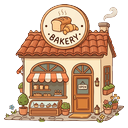
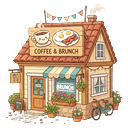
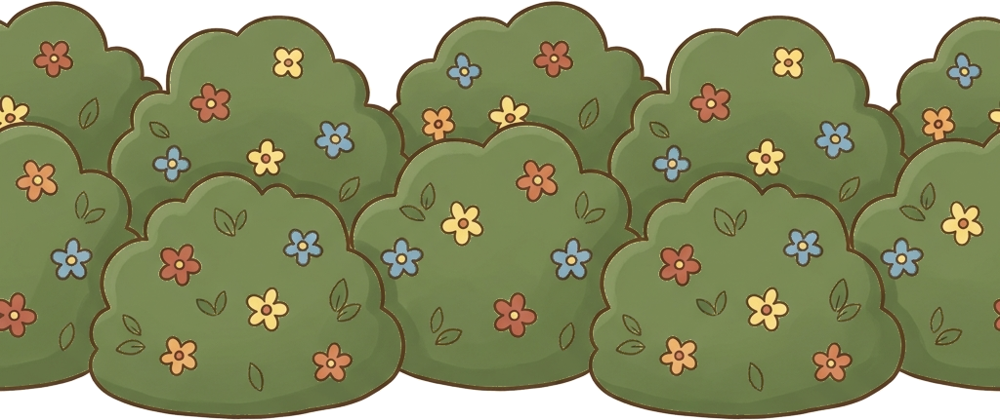
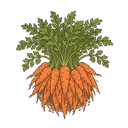
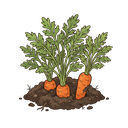
...
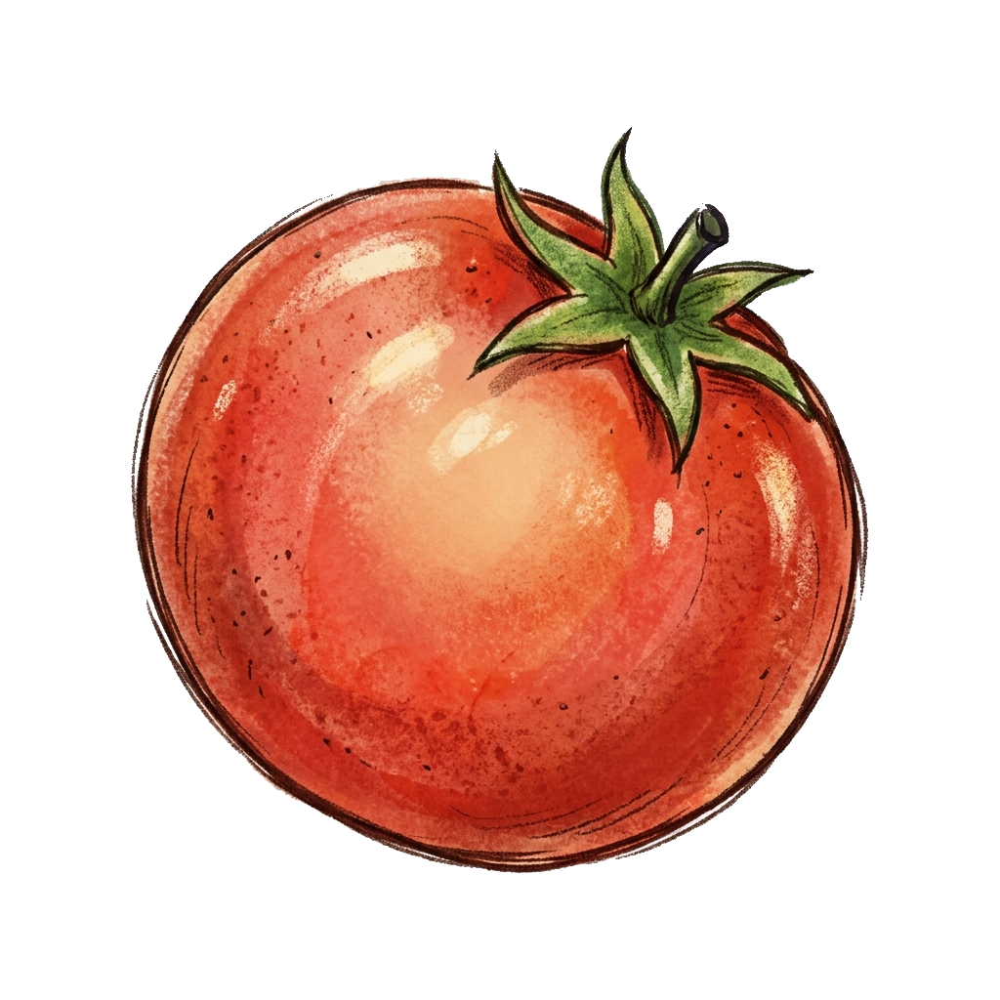
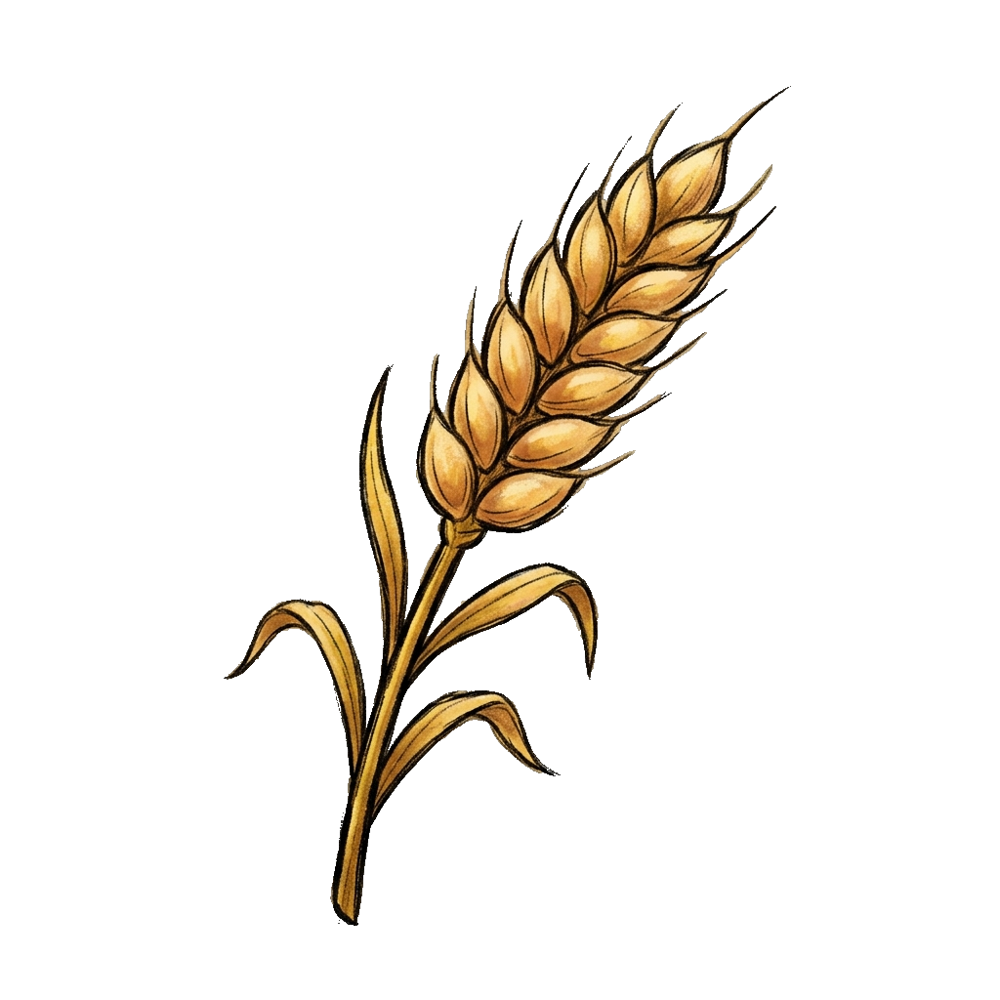
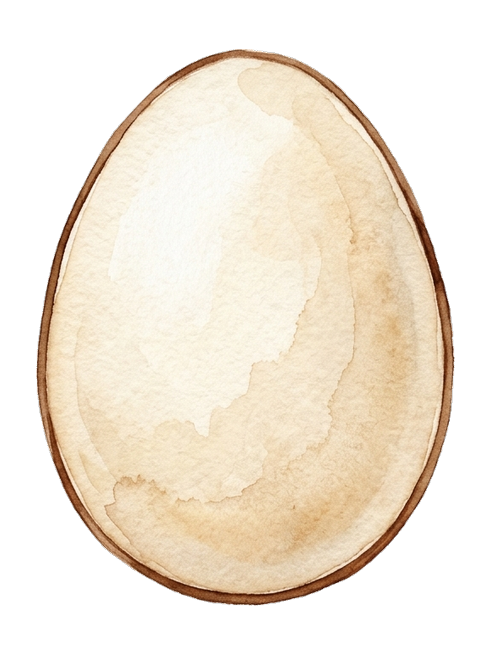
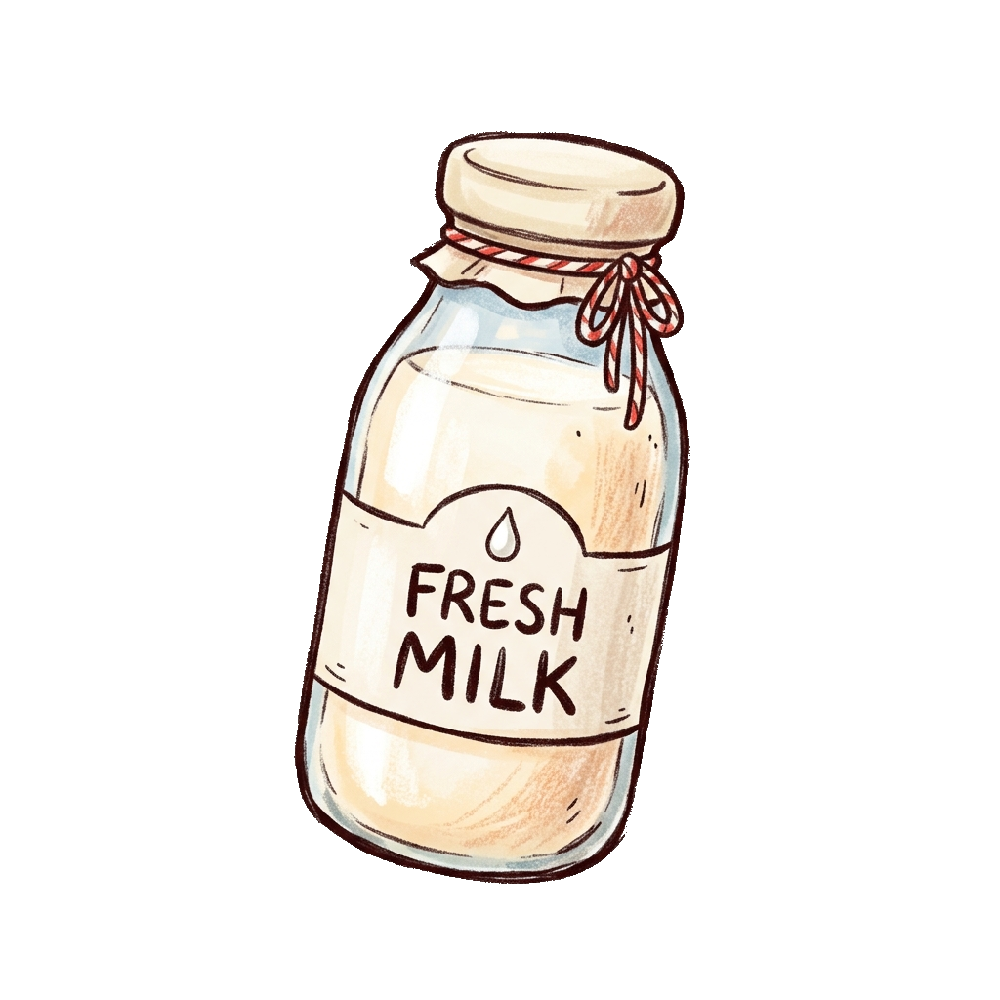
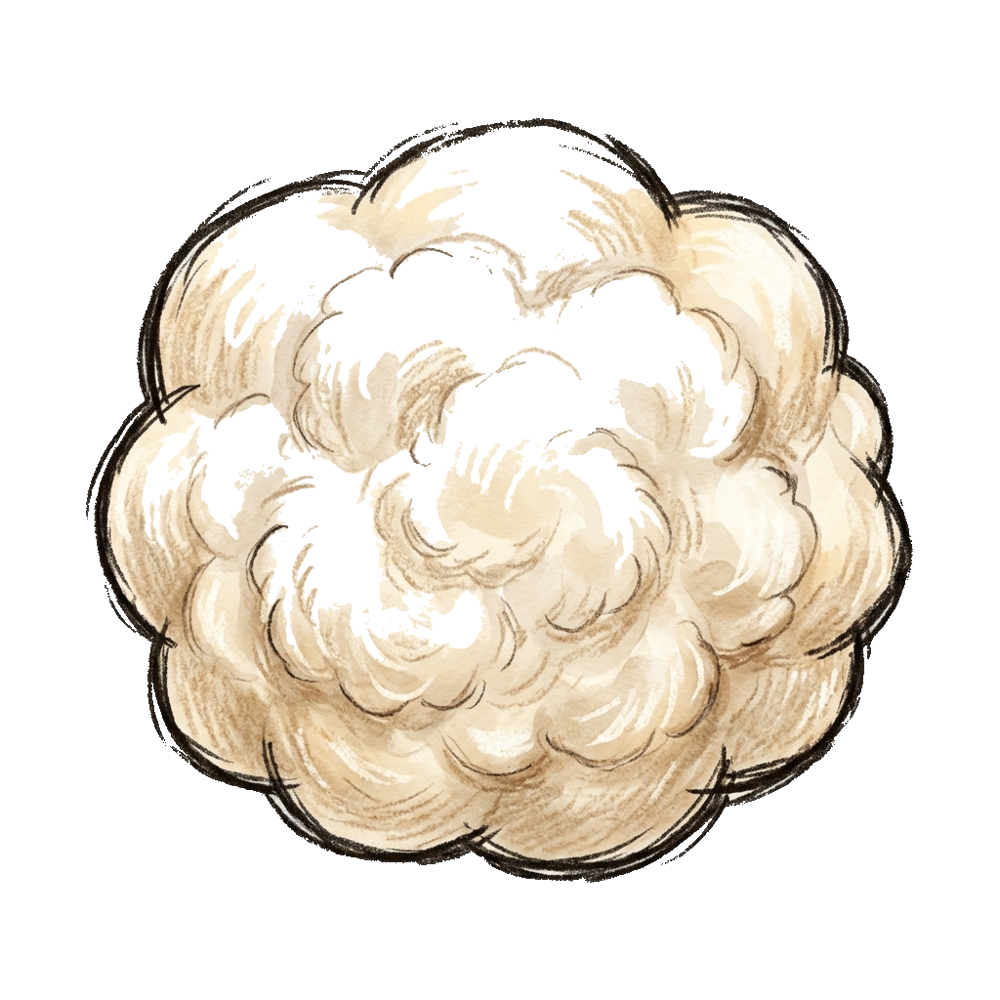

In [25]:
# Test it against the random agent
# Agent mode:
#   - `ranadom`: random_agent
#   - `starter`: starter_agent
#   - `pass`: pass_agent
from IPython.display import display, HTML

env = make("kaggriculture", debug=True)
env.run(["random", "random"])

final = env.steps[-1]
for i, s in enumerate(final):
    print(f"Player {i}: reward={s.reward}, status={s.status}")

html = env.render(mode="html", width=300, height=300)

display(HTML(html))

In [ ]:
# Gets complete season episodes (days/hours) events
complete_season = env.steps
season = pd.DataFrame.from_dict(complete_season, orient="columns")

# Gets wrt players (agent defaults to 0 as configured) -- observations, actions
agt_history = pd.json_normalize(season[0])
opp_history = pd.json_normalize(season[1])

In [ ]:
# [
#     i for i in agt_history.columns if "observation" in i
# ]  # private.shed, private.seeds, private.inventories, market.inventory, market.prices
from collections import defaultdict

OBS_COLS = defaultdict(list)
ACTION_COLS = ["action.farmer", "action.market", "action.hands"]
STATE_COLS = [
    "observation.day",
    "observation.hour",
    "observation.remainingOverageTime",
    "observation.player",
    "observation.farms",
]

AGENT_INDEX = 0

for label in [
    "private.shed",
    "private.seeds",
    "private.inventories",
    "market.inventory",
    "market.prices",
    # "town.unlocked_shops"
]:
    tag = label.split(".")[-1] if "market" not in label else label
    print(f"setting {tag} to OBS_COLS")

    OBS_COLS.setdefault(
        tag, [i for i in agt_history.columns if f"observation.{label}" in i]
    )

setting shed to OBS_COLS
setting seeds to OBS_COLS
setting inventories to OBS_COLS
setting market.inventory to OBS_COLS
setting market.prices to OBS_COLS


#### OBSERVATIONS

In [ ]:
opp_history[OBS_COLS["market.inventory"]].describe(
    include=["mean", "std", "min", "max"]
)

,observation.market.inventory.WHEAT,observation.market.inventory.CARROT,observation.market.inventory.TOMATO,observation.market.inventory.STRAWBERRY,observation.market.inventory.MELON,observation.market.inventory.EGG,observation.market.inventory.MILK,observation.market.inventory.WOOL,observation.market.inventory.FERTILIZER
count,720.000000,720.000000,720.000000,720.000000,720.000000,720.000000,720.000000,720.000000,720.0
mean,9877.791667,9976.366667,9976.366667,9742.341667,9984.541667,9912.241667,9808.316667,9984.541667,10000.0
std,124.706882,22.366874,22.366874,229.906239,8.663766,75.649675,170.304823,8.663766,0.0
min,9574.000000,9916.000000,9916.000000,9250.000000,9970.000000,9754.000000,9448.000000,9970.000000,10000.0
25%,9797.000000,9968.000000,9968.000000,9563.000000,9977.000000,9851.000000,9671.000000,9977.000000,10000.0
50%,9931.000000,9985.000000,9985.000000,9805.000000,9985.000000,9931.000000,9859.000000,9985.000000,10000.0
75%,9983.000000,9992.000000,9992.000000,9956.000000,9992.000000,9983.000000,9965.000000,9992.000000,10000.0
max,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.0


In [82]:
opp_history[OBS_COLS["market.prices"]].describe()

,observation.market.prices.WHEAT,observation.market.prices.CARROT,observation.market.prices.TOMATO,observation.market.prices.STRAWBERRY,observation.market.prices.MELON,observation.market.prices.EGG,observation.market.prices.MILK,observation.market.prices.WOOL,observation.market.prices.FERTILIZER
count,720.000000,720.000000,720.000000,720.000000,720.000000,720.000000,720.000000,720.000000,720.0
mean,34.298611,36.801389,62.813889,236.325000,272.758333,55.251389,264.322222,222.326389,100.0
std,5.960090,1.780203,2.720923,68.239046,6.329606,4.611695,60.055899,6.190115,0.0
min,25.000000,35.000000,60.000000,120.000000,250.000000,50.000000,160.000000,200.000000,100.0
25%,29.000000,36.000000,61.000000,176.000000,269.000000,51.000000,211.000000,219.000000,100.0
50%,33.000000,36.000000,62.000000,237.000000,274.000000,54.000000,263.000000,224.000000,100.0
75%,39.000000,37.000000,64.000000,296.000000,278.000000,59.000000,318.000000,227.000000,100.0
max,46.000000,42.000000,70.000000,350.000000,280.000000,65.000000,364.000000,229.000000,100.0


In [70]:
agt_history[OBS_COLS["seeds"]].describe()

,observation.private.seeds.WHEAT,observation.private.seeds.CARROT,observation.private.seeds.TOMATO,observation.private.seeds.STRAWBERRY,observation.private.seeds.MELON
count,720.000000,720.000000,720.000000,720.000000,720.000000
mean,10.109722,2.487500,6.736111,4.673611,7.477778
std,5.386886,1.655222,4.084616,2.631863,2.780732
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,5.000000,1.000000,3.000000,2.000000,4.000000
50%,13.000000,2.000000,8.000000,6.000000,8.000000
75%,15.000000,4.250000,11.000000,7.000000,10.000000
max,15.000000,5.000000,11.000000,8.000000,10.000000


In [83]:
agt_history[OBS_COLS["shed"]].describe()

,observation.private.shed.WHEAT,observation.private.shed.CARROT,observation.private.shed.TOMATO,observation.private.shed.STRAWBERRY,observation.private.shed.MELON,observation.private.shed.EGG,observation.private.shed.MILK,observation.private.shed.WOOL,observation.private.shed.FERTILIZER,observation.private.shed.GOOSE,observation.private.shed.COW,observation.private.shed.SHEEP
count,720.0,720.0,720.0,720.0,720.0,720.0,720.0,720.0,720.0,720.0,720.0,720.0
mean,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
std,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
min,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
25%,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
50%,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
75%,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
max,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


#### ACTIONS

In [ ]:
# action.farmer = ['CARROT',
#  'EAST',
#  'HARVEST',
#  'MELON',
#  'NORTH',
#  'PASS',
#  'PLANT',
#  'SOUTH',
#  'STRAWBERRY',
#  'TOMATO',
#  'WATER',
#  'WEST',
#  'WHEAT']

# action.market = [nan, 'BUY_SEED', 'MELON', 1, 'TOMATO', 'STRAWBERRY', 'WHEAT', 'CARROT'],
# action.hands IDLE

##### COLS
# _TABLE_ACTION_COLS = ['action.farmer', 'action.hands', 'action.market']
# _TABLE_OBS_PRIVATE_COLS = ['observation.private.shed.WHEAT',

#  'observation.private.shed.CARROT',
#  'observation.private.shed.TOMATO',
#  'observation.private.shed.STRAWBERRY',
#  'observation.private.shed.MELON',
#  'observation.private.shed.EGG',
#  'observation.private.shed.MILK',
#  'observation.private.shed.WOOL',
#  'observation.private.shed.FERTILIZER',
#  'observation.private.shed.GOOSE',
#  'observation.private.shed.COW',
#  'observation.private.shed.SHEEP',
#  'observation.private.seeds.WHEAT',
#  'observation.private.seeds.CARROT',
#  'observation.private.seeds.TOMATO',
#  'observation.private.seeds.STRAWBERRY',
#  'observation.private.seeds.MELON',
#  'observation.private.inventories']


[i for i in opp_history.columns if i.startswith("action")]

['action.farmer', 'action.hands', 'action.market']

#### STATES

In [ ]:
?np.where

array([['*', '*', '*', 'LOCKED', '*', 'LOCKED', 'LOCKED', 'LOCKED',
        'LOCKED', 'LOCKED'],
       ['*', '*', 'LOCKED', 'LOCKED', 'LOCKED', 'LOCKED', 'LOCKED',
        'LOCKED', 'LOCKED', 'LOCKED'],
       ['*', '*', 'LOCKED', 'LOCKED', 'LOCKED', 'LOCKED', 'LOCKED',
        'LOCKED', 'LOCKED', 'LOCKED'],
       ['*', '*', '*', 'LOCKED', 'LOCKED', 'LOCKED', 'LOCKED', 'LOCKED',
        'LOCKED', 'LOCKED'],
       ['*', '*', 'LOCKED', 'LOCKED', 'LOCKED', 'LOCKED', 'LOCKED',
        'LOCKED', 'LOCKED', 'LOCKED'],
       ['LOCKED', 'LOCKED', 'LOCKED', 'LOCKED', 'LOCKED', 'LOCKED',
        'LOCKED', 'LOCKED', 'LOCKED', 'LOCKED'],
       ['LOCKED', 'LOCKED', 'LOCKED', 'LOCKED', 'LOCKED', 'LOCKED',
        'LOCKED', 'LOCKED', 'LOCKED', 'LOCKED'],
       ['LOCKED', 'LOCKED', 'LOCKED', 'LOCKED', 'LOCKED', 'LOCKED',
        'LOCKED', 'LOCKED', 'LOCKED', 'LOCKED'],
       ['LOCKED', 'LOCKED', 'LOCKED', 'LOCKED', 'LOCKED', 'LOCKED',
        'LOCKED', 'LOCKED', 'LOCKED', 'LOCKED'],
       ['LOC

In [ ]:
LAST_HOUR = TURNS_PER_DAY - 1  # 23
LAST_DAY = SEASON_DAYS - 1  # 29
MAX_HANDS = 10  # past this, fib costs and the 10-order cap bite
MIN_USEFUL_TURNS = 4  # don't hire a hand that can barely work today


def _me(obs) -> int:
    return obs["player"]


def _farm(obs) -> dict:
    return obs["farms"][_me(obs)]


def _tile(obs, unit_pos):
    x, y = unit_pos
    return _farm(obs)["tiles"][y][x]


def _is_plant(tile) -> bool:
    return isinstance(tile, dict) and tile.get("kind") == "PLANT"


def _is_animal(tile) -> bool:
    return isinstance(tile, dict) and "animal" in tile and tile.get("animal")


def _inventory(obs, unit_idx: int) -> dict:
    invs = obs["private"].get("inventories") or []
    return invs[unit_idx] if unit_idx < len(invs) else {}


def _step(obs) -> int:
    return obs["day"] * TURNS_PER_DAY + obs["hour"]


def unit_positions(obs) -> list[tuple[int, int]]:
    """[farmer, hand1, hand2, ...] as (x, y) tuples."""
    f = _farm(obs)
    return [tuple(f["farmer"])] + [tuple(h) for h in f.get("hands", [])]


def fib(n: int) -> int:
    """Engine's hire-cost sequence: fib(0)=1, fib(1)=1, fib(2)=2, fib(3)=3, fib(4)=5 ..."""
    a, b = 1, 1
    for _ in range(n):
        a, b = b, a + b
    return a


def window_start(crop: str) -> int:
    """First age at which watering adds yield (one-time crops): ceil(max_yield_day / 2)."""
    return (CROPS[crop]["max_yield_day"] + 1) // 2


def get_best_harvest_age(crop: str) -> int:
    """Age at which yield peaks with daily watering (no fertilizer).

    One-time: the day the cap is reached (WHEAT 4, CARROT 3, MELON 10).
    Ongoing:  the age of the last scheduled production (TOMATO 11, STRAWBERRY 16).
    """
    c = CROPS[crop]
    if c["ongoing"]:
        return c["first_yield_day"] + c["interval"] * (c["max_yield"] - 1)
    y, best = 1, c["first_yield_day"]
    for age in range(window_start(crop), c["max_yield_day"] + 1):
        if y < c["max_yield"]:
            y += 1
            best = age
    return max(best, c["first_yield_day"])


def can_plant(obs, unit_pos, crop, planting_now: dict) -> bool:
    """planting_now: crop -> number of units already assigned PLANT this turn."""
    me = obs["player"]
    x, y = unit_pos
    tile = obs["farms"][me]["tiles"][y][x]
    seeds = obs["private"]["seeds"].get(crop, 0)
    return (
        crop in CROPS
        and tile is None  # empty, unlocked, no weed
        and planting_now.get(crop, 0) + 1 <= seeds  # conflict rule
        and obs["hour"] <= 22  # time left to water today
        and obs["day"] + get_best_harvest_age(crop) <= 29
    )


def can_water(
    obs, unit_pos, watering_now: set | None = None, strategic: bool = True
) -> bool:
    """watering_now: tiles another unit is already watering this turn.

    Engine: tile is a plant not yet watered today.
    Strategic: skip if another unit has it covered this turn (the second
    WATER would be a wasted turn). Watering is otherwise always worth it:
    it keeps the plant alive and, in the bonus window, adds yield.
    """
    tile = _tile(obs, unit_pos)
    valid = _is_plant(tile) and not tile["watered_today"]
    if not valid or not strategic:
        return valid
    return tuple(unit_pos) not in (watering_now or set())


def water_urgency(obs, unit_pos) -> int:
    """0 = dies tonight if not watered, 1 = watering adds yield today,
    2 = routine. Use it as a task priority. Returns -1 if no water needed."""
    tile = _tile(obs, unit_pos)
    if not (_is_plant(tile) and not tile["watered_today"]):
        return -1
    if tile["consecutive_unwatered"] >= 1:
        return 0
    c = CROPS[tile["crop"]]
    age = obs["day"] - tile["planted_day"]
    if (
        not c["ongoing"]
        and window_start(tile["crop"]) <= age <= c["max_yield_day"]
        and tile["yield_units"] < c["max_yield"]
    ):
        return 1
    return 2


def can_harvest(
    obs, unit_pos, harvesting_now: set | None = None, strategic: bool = True
) -> bool:
    """harvesting_now: tiles another unit is already harvesting this turn.

    Engine: plant with yield > 0 and age >= first_yield_day, or animal with yield > 0.

    Strategic, one-time crops (harvest removes the plant, so timing matters):
      harvest when yield has peaked (age >= best harvest age, or at max_yield),
      when decay has started, or on the last day.
    Strategic, ongoing crops and animals: harvest whenever there is yield
      (production is capped, so waiting only risks hitting the cap).
    """

    tile = _tile(obs, unit_pos)
    if not isinstance(tile, dict) or tile.get("yield_units", 0) <= 0:
        return False
    if _is_plant(tile):
        c = CROPS[tile["crop"]]
        age = obs["day"] - tile["planted_day"]
        valid = age >= c["first_yield_day"]
    else:
        valid = bool(_is_animal(tile))
    if not valid or not strategic:
        return valid

    if tuple(unit_pos) in (harvesting_now or set()):
        return False
    if not _is_plant(tile) or CROPS[tile["crop"]]["ongoing"]:
        return True
    c = CROPS[tile["crop"]]
    age = obs["day"] - tile["planted_day"]
    decaying = 0 <= tile["max_lifespan_step"] <= _step(obs)
    return (
        age >= get_best_harvest_age(tile["crop"])
        or tile["yield_units"] >= c["max_yield"]
        or decaying
        or obs["day"] == LAST_DAY
    )


def fertilize_gain(obs, unit_pos) -> int:
    """Extra units of yield expected from fertilizing this plant NOW.

    Fertilizer covers days [day, day + 2] (engine: fertilized_until_day = day + 2),
    minus days already covered.

    One-time crops: +1 extra per covered day that is inside the bonus window
      AND still gets a WATER this day (not already watered today), capped by
      max_yield headroom. Note: fertilize BEFORE watering on the same day.
    Ongoing crops: +1 extra per covered day with a scheduled production
      (production is checked at end of day, so today's order doesn't matter),
      capped by the remaining production count.
    """
    tile = _tile(obs, unit_pos)
    if not _is_plant(tile):
        return 0
    crop, day = tile["crop"], obs["day"]
    c = CROPS[crop]
    age0 = day - tile["planted_day"]
    already = tile.get("fertilized_until_day", -1)
    new_days = [d for d in range(day, day + 3) if d > already and d <= LAST_DAY]

    if not c["ongoing"]:
        lo, hi = window_start(crop), c["max_yield_day"]
        extra = 0
        for d in new_days:
            age = age0 + (d - day)
            if not (lo <= age <= hi):
                continue
            if d == day and tile["watered_today"]:
                continue  # today's water bonus already paid at x1
            extra += 1
        # Headroom: cap minus current yield minus normal (x1) bonuses still to come.
        normal_left = sum(
            1
            for age in range(max(age0, lo), hi + 1)
            if not (age == age0 and tile["watered_today"])
        )
        headroom = c["max_yield"] - tile["yield_units"] - normal_left
        return max(0, min(extra, headroom))

    # Ongoing: productions fire at end of day d for next_day = d + 1.
    extra, first, iv = 0, c["first_yield_day"], c["interval"]
    for d in new_days:
        since = (d + 1) - tile["planted_day"] - first
        if since >= 0 and since % iv == 0 and since // iv + 1 <= c["max_yield"]:
            extra += 1
    return extra


def can_fertilize(
    obs,
    unit_pos,
    unit_idx: int,
    fertilizing_now: set | None = None,
    strategic: bool = True,
    min_gain: int = 1,
) -> bool:
    """unit_idx: 0 = farmer, i = hand i (fertilizer comes from THIS unit's inventory).

    Engine: tile is a plant and the unit carries FERTILIZER. Fertilizer is
    consumed even if it gives no benefit, so the strategic check matters.
    Strategic: expected gain >= min_gain units and no other unit fertilizing
    the same tile this turn.
    """
    tile = _tile(obs, unit_pos)
    valid = _is_plant(tile) and _inventory(obs, unit_idx).get("FERTILIZER", 0) >= 1
    if not valid or not strategic:
        return valid
    if tuple(unit_pos) in (fertilizing_now or set()):
        return False
    return fertilize_gain(obs, unit_pos) >= min_gain

In [ ]:
tiles = np.vstack(
    pd.json_normalize(pd.json_normalize(opp_history["observation.farms"])[AGENT_INDEX])
    .iloc[-1]
    .tiles
)

array([[None, None, None, {'kind': 'WEED'}, None, 'LOCKED', 'LOCKED',
        'LOCKED', 'LOCKED', 'LOCKED'],
       [None, None, {'kind': 'WEED'}, {'kind': 'WEED'}, {'kind': 'WEED'},
        'LOCKED', 'LOCKED', 'LOCKED', 'LOCKED', 'LOCKED'],
       [None, None, {'kind': 'WEED'}, {'kind': 'WEED'}, {'kind': 'WEED'},
        'LOCKED', 'LOCKED', 'LOCKED', 'LOCKED', 'LOCKED'],
       [None, None, None, {'kind': 'WEED'}, {'kind': 'WEED'}, 'LOCKED',
        'LOCKED', 'LOCKED', 'LOCKED', 'LOCKED'],
       [None, None, {'kind': 'WEED'}, {'kind': 'WEED'}, {'kind': 'WEED'},
        'LOCKED', 'LOCKED', 'LOCKED', 'LOCKED', 'LOCKED'],
       ['LOCKED', 'LOCKED', 'LOCKED', 'LOCKED', 'LOCKED', 'LOCKED',
        'LOCKED', 'LOCKED', 'LOCKED', 'LOCKED'],
       ['LOCKED', 'LOCKED', 'LOCKED', 'LOCKED', 'LOCKED', 'LOCKED',
        'LOCKED', 'LOCKED', 'LOCKED', 'LOCKED'],
       ['LOCKED', 'LOCKED', 'LOCKED', 'LOCKED', 'LOCKED', 'LOCKED',
        'LOCKED', 'LOCKED', 'LOCKED', 'LOCKED'],
       ['LOCKED', 'L

## What's wrong with this agent?

The melon agent has a few problems:
  - It never hires farm hands or buys more land, so it's stuck with one farmer working a single quadrant.     
  - It only grows melons, so when other crops are fetching a higher price it has nothing to sell.
  - It never fertilizes its plants, leaving a yield bonus on the table.                           
  - When it does sell, it dumps the entire inventory in one order, which can crash the melon price below the       
  threshold partway through the sale.                                                                         
                                      
Now it's your turn to make improvements!

In [ ]:
import numpy as np


class Bandit:
    """k-armed Gaussian testbed: each arm pays N(mean[arm], 1)."""

    def __init__(self, arms: int = 10, drift: float = 0.01, seed: int | None = None):
        self.arms = arms
        self.drift = drift
        self.rng = np.random.default_rng(seed)
        self.means = self.rng.normal(loc=0.0, scale=1.0, size=arms)

    def select(self, arm: int) -> tuple[float, int]:
        """Pull one arm. Returns (reward, 1 if it was the best arm else 0)."""
        reward = self.rng.normal(loc=self.means[arm], scale=1.0)
        optimal = int(arm == np.argmax(self.means))
        return reward, optimal

    def disturb(self) -> None:
        """Random-walk every arm's mean (non-stationary bandit)."""
        self.means += self.rng.normal(loc=0.0, scale=self.drift, size=self.arms)